Bus Number to Name Mapping:
Bus 2135: NPOLP_2     220.00
Bus 2220: KOTMA-2     220.00
Bus 2222: BARGE-2     220.00
Bus 2225: UPPER-KOTH-2220.00
Bus 2230: VICTO-2     220.00
Bus 2240: RANDE-2     220.00
Bus 2245: VAVUNIYA-2  220.00
Bus 2250: RANTE-2     220.00
Bus 2280: MANNAR-2    220.00
Bus 2281: NADUKUDA-2  220.00
Bus 2300: KELAN-2     220.00
Bus 2305: KERAWALA_2  220.00
Bus 2306: NEW_KERA2   220.00
Bus 2307: NEW_KERA    220.00
Bus 2350: COL_L2      220.00
Bus 2400: HAMBAN-2    220.00
Bus 2560: PANNI-2     220.00
Bus 2561: PANNI-D-2   220.00
Bus 2570: BIYAG-2     220.00
Bus 2580: KOTUG-2     220.00
Bus 2691: NHAB-2      220.00
Bus 2705: NEWANU-2    220.00
Bus 2810: PUTTALAM-PS 220.00
Bus 2815: NCHILAW-2   220.00
Bus 2830: VEYAN-2     220.00
Bus 2970: PADUKKA_2   220.00
[(2135, 2220), (2135, 2400), (2135, 2970), (2220, 2225), (2220, 2230), (2220, 2570), (2220, 2691), (2222, 2300), (2230, 2240), (2240, 2250), (2245, 2280), (2245, 2705), (2280, 2281), (2300, 2570), (2305, 2306), (2305, 

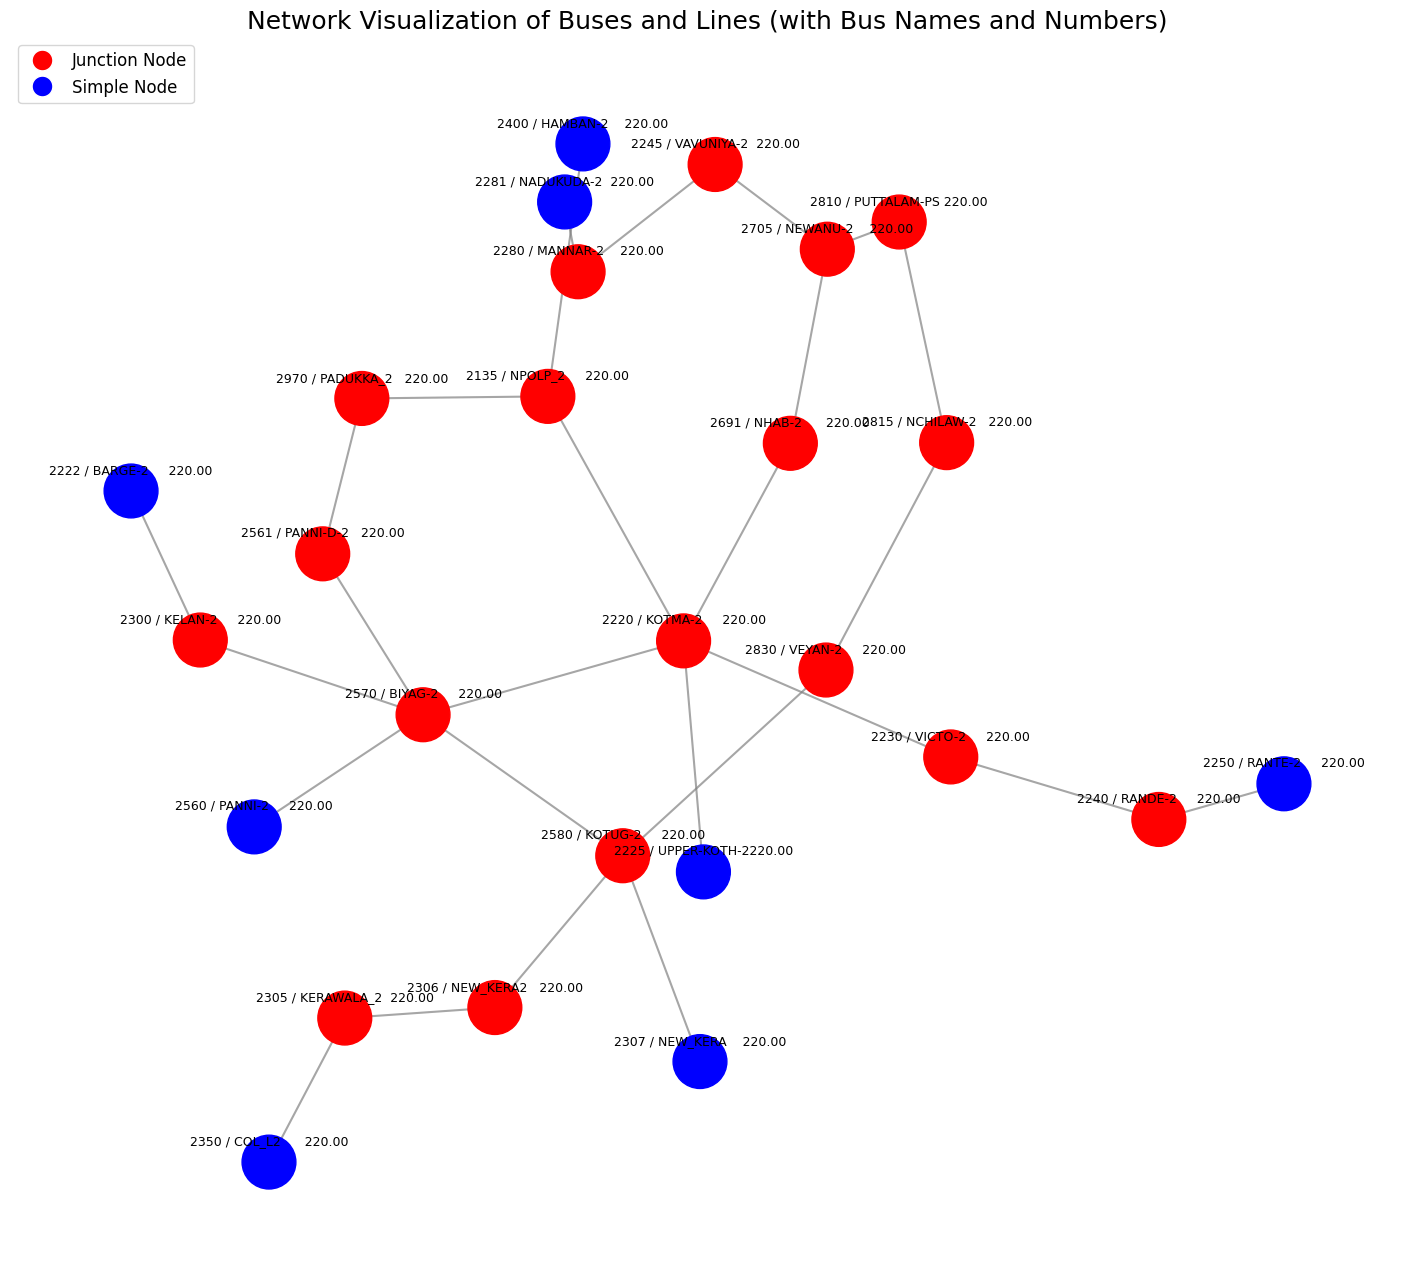

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ABCD_combined = pd.read_csv('ABCD_5.csv')
branch_data = pd.read_csv('branch.csv')

# Create a mapping from bus number to bus name - MOVED TO TOP
bus_num_to_name = {}

# Iterate through branch_data to build the mapping
for index, row in branch_data.iterrows():
    # Convert to int, handling potential float/complex if present
    from_num = int(row['From Bus  Number'])
    from_name = row['From Bus  Name'].strip() # Strip whitespace from name
    to_num = int(row['To Bus  Number'])
    to_name = row['To Bus  Name'].strip() # Strip whitespace from name

    # Store the mapping (assuming consistency, or taking the last one if duplicates)
    bus_num_to_name[from_num] = from_name
    bus_num_to_name[to_num] = to_name

print("Bus Number to Name Mapping:")
for num, name in sorted(bus_num_to_name.items()):
    print(f"Bus {num}: {name}")

def connection_matrix(ABCD_combined):
    # Clean and extract unique buses
    buses = pd.unique(ABCD_combined[['From Bus Number', 'To Bus Number']].values.ravel())

    # Sort buses for readability (optional)
    buses = np.sort(buses)

    # Map bus numbers to index
    bus_index = {bus: idx for idx, bus in enumerate(buses)}
    n = len(buses)

    # Initialize connection matrix
    connection_matrix = np.zeros((n, n), dtype=int)

    # Build the adjacency (connection) matrix
    for _, row in ABCD_combined.iterrows():
        from_idx = bus_index[row['From Bus Number']]
        to_idx = bus_index[row['To Bus Number']]
        connection_matrix[from_idx, to_idx] = 1
        connection_matrix[to_idx, from_idx] = 1  # undirected

    # Create DataFrame with formatted bus names
    bus_labels = [f"{bus.real:+.1f}+{bus.imag:+.1f}j" if isinstance(bus, complex) else f"{bus:.1f}+0.0j" for bus in buses]
    connection_df = pd.DataFrame(connection_matrix, index=bus_labels, columns=bus_labels)
    return connection_df

# Create the connection matrix DataFrame
connection_matrix_df = connection_matrix(ABCD_combined)


conn_df = connection_matrix_df

# Convert to numpy matrix (still 0/1)
conn_np = conn_df.values

# Number of nodes
N = conn_np.shape[0]

# Map labels like "2135.0+0.0j" to numbers like 2135 (FIXED)
node_labels = list(conn_df.index)
node_numbers = [int(float(label.split('+')[0])) for label in node_labels]


lines = []

for i in range(N):
    for j in range(i+1, N):
        if conn_np[i, j] == 1:
            bus_i = node_numbers[i]
            bus_j = node_numbers[j]
            lines.append((bus_i, bus_j))

print(lines)

# Create node_to_lines mapping (ADDED)
node_to_lines = {}
for line_idx, (bus_i, bus_j) in enumerate(lines):
    if bus_i not in node_to_lines:
        node_to_lines[bus_i] = []
    node_to_lines[bus_i].append(line_idx)
    if bus_j not in node_to_lines:
        node_to_lines[bus_j] = []
    node_to_lines[bus_j].append(line_idx)


def connection_matrix_with_labels(ABCD_combined):
    # Extract unique buses
    buses = pd.unique(ABCD_combined[['From Bus Number', 'To Bus Number']].values.ravel())
    buses = np.sort(buses)

    # Map bus numbers to index (this is still useful for internal matrix indexing)
    bus_index = {bus: idx for idx, bus in enumerate(buses)}
    n = len(buses)

    # Initialize connection matrix
    conn_matrix = np.zeros((n, n), dtype=int)

    # Fill matrix
    for _, row in ABCD_combined.iterrows():
        from_idx = bus_index[row['From Bus Number']]
        to_idx = bus_index[row['To Bus Number']]
        conn_matrix[from_idx, to_idx] = 1
        conn_matrix[to_idx, from_idx] = 1  # undirected

    # Create DataFrame with actual bus names as labels
    # Use bus_num_to_name to get actual names. Convert bus.real to int as keys in bus_num_to_name are ints.
    bus_names = [bus_num_to_name.get(int(bus.real), f"Bus {int(bus.real)}") for bus in buses]

    conn_df = pd.DataFrame(conn_matrix, index=bus_names, columns=bus_names)

    return conn_df

# Example usage:
connection_matrix_df = connection_matrix_with_labels(ABCD_combined)


G = nx.Graph()

# Get bus names directly from the connection_matrix_df index
bus_names = connection_matrix_df.index.tolist()

# Add nodes (buses) using their actual names
for name in bus_names:
    G.add_node(name)

# Add edges (lines)
# Convert line (bus_i, bus_j) from numbers to names using the correct mapping
for line_idx, (bus_num_i, bus_num_j) in enumerate(lines):
    bus_name_i = bus_num_to_name[bus_num_i] # Corrected to use bus_num_to_name
    bus_name_j = bus_num_to_name[bus_num_j] # Corrected to use bus_num_to_name
    G.add_edge(bus_name_i, bus_name_j, line_index=line_idx)

# Identify junction nodes (nodes connected to more than one line)
# Use the original node_to_lines mapping which is based on bus numbers, then convert to names
junction_node_nums = [node for node, connections in node_to_lines.items() if len(connections) > 1]
# Convert junction bus numbers to names using the correct mapping
junction_nodes = [bus_num_to_name[num] for num in junction_node_nums] # Corrected to use bus_num_to_name

# Create a list of node colors for visualization
node_colors = ['red' if node in junction_nodes else 'blue' for node in G.nodes()]

# Draw the graph
plt.figure(figsize=(18, 16)) # Increase figure size further

# Using fruchterman_reingold_layout for potentially clearer separation
pos = nx.fruchterman_reingold_layout(G, k=0.8, iterations=100)  # Increased k for more spread

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500) # Increase node size
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7, edge_color='gray') # Make edges a bit thicker and colored

# Create labels with both sequential number and bus name
node_labels = {}
for bus_name in G.nodes():
    # We need to find the original bus number for the sequential numbering
    # Iterate through bus_num_to_name to find the key (bus number) for the current bus_name
    original_bus_num = None
    for num, name in bus_num_to_name.items():
        if name == bus_name:
            original_bus_num = num
            break
    if original_bus_num is not None:
        node_labels[bus_name] = f"{original_bus_num} / {bus_name}"
    else:
        node_labels[bus_name] = bus_name # Fallback if bus name not found in mapping

# Offset labels slightly above nodes
label_pos = {node: (x, y + 0.03) for node, (x, y) in pos.items()} # Adjust Y-coordinate for labels
nx.draw_networkx_labels(G, label_pos, labels=node_labels, font_size=9, font_color='black') # Use custom labels with offset

# Create custom legend handles
red_patch = plt.Line2D([0], [0], marker='o', color='w', label='Junction Node',
                        markerfacecolor='red', markersize=15) # Larger marker for legend
blue_patch = plt.Line2D([0], [0], marker='o', color='w', label='Simple Node',
                         markerfacecolor='blue', markersize=15) # Larger marker for legend
plt.legend(handles=[red_patch, blue_patch], loc='upper left', fontsize=12) # Move legend and increase font

plt.title("Network Visualization of Buses and Lines (with Bus Names and Numbers)", fontsize=18) # Increase title font size
plt.axis('off') # Hide axes
plt.show()